In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
ccd= pd.read_csv("Customer_churn_data.csv")
ccd

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes


In [3]:
ccd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [4]:
ccd.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [5]:
ccd.duplicated().sum()

0

In [6]:
ccd.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [7]:
ccd.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [8]:
ccd['InternetService']=ccd['InternetService'].fillna("")

In [9]:
ccd.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [10]:
numeric_columns_data = ccd.select_dtypes(include=["number"])

In [11]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

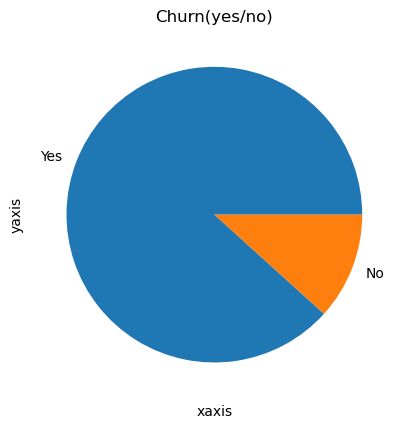

In [12]:
ccd['Churn'].value_counts().plot(kind="pie")
plt.title("Churn(yes/no)")
plt.xlabel("xaxis")
plt.ylabel("yaxis")
plt.show

In [13]:
ccd.groupby(["Churn","Gender","CustomerID"])['MonthlyCharges'].mean()

Churn  Gender  CustomerID
No     Female  9              49.81
               12             36.18
               16             89.11
               27             98.99
               38             47.55
                              ...  
Yes    Male    994           102.27
               996            37.14
               997            80.93
               999            65.67
               1000           56.67
Name: MonthlyCharges, Length: 1000, dtype: float64

In [14]:
ccd.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [15]:
ccd.groupby("Churn")['Tenure'].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

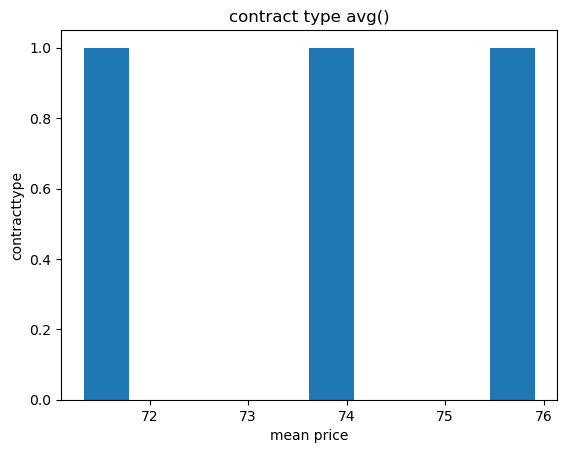

In [16]:
ccd.groupby("ContractType")['MonthlyCharges'].mean().plot(kind="hist")
plt.xlabel("mean price")
plt.ylabel("contracttype")
plt.title("contract type avg()")
plt.show()

In [17]:
ccd

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,,4465.56,No,Yes


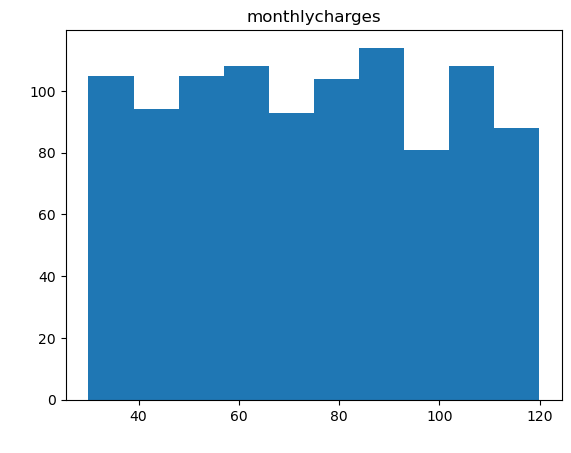

In [18]:
plt.hist(ccd["MonthlyCharges"])
plt.title("monthlycharges")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

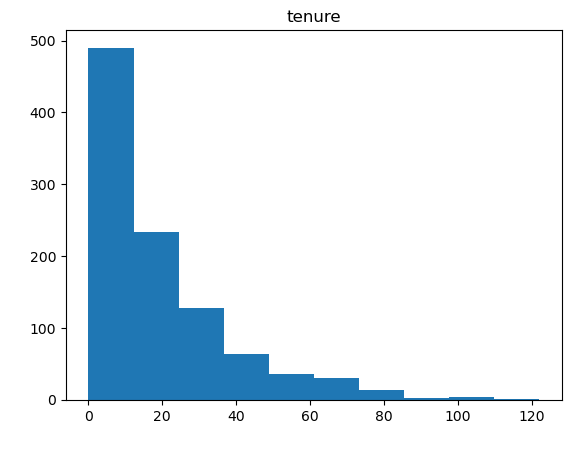

In [19]:
plt.hist(ccd['Tenure'])
plt.title("tenure")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

In [20]:
ccd.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [21]:
Y = ccd[['Churn']]
X = ccd[['Age','Gender','Tenure','MonthlyCharges']]

In [22]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [41]:
X['Gender'] = X['Gender'].apply(lambda x:1 if x == "Female" else 0)

In [24]:
X['Gender'][0]

0

In [42]:
Y['Churn'] = Y['Churn'].apply(lambda x:1 if x == "Yes" else 0)

In [26]:
type(Y['Churn'][1])

numpy.int64

In [27]:
 from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2)

In [28]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
Scaler = StandardScaler()

In [31]:
X_train = Scaler.fit_transform (X_train)

In [32]:
import joblib
joblib.dump(Scaler, "Scaler.pkl")

['Scaler.pkl']

In [33]:
X_test = Scaler.fit_transform(X_test)

In [34]:
X_train

array([[ 0.43775997,  0.95836592,  2.68671216, -0.25711334],
       [ 1.05090496,  0.95836592, -0.68261849, -0.74918698],
       [-0.27757585,  0.95836592,  2.16025425, -0.32134764],
       ...,
       [ 2.1750041 ,  0.95836592, -0.99849324,  0.43544916],
       [-0.48195751,  0.95836592,  0.94940104, -1.23542114],
       [ 0.33556914,  0.95836592, -0.78791008,  0.75545274]])

In [1]:
X_test

NameError: name 'X_test' is not defined

In [36]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("accuracy score on model is {}".format(accuracy_score(Y_test,predictions)))

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
from sklearn.linear_model import LogisticRegression 

In [39]:
log_model = LogisticRegression()

In [43]:
import warnings
warnings.filterwarnings("ignore")

In [44]:
log_model.fit(X_train, Y_train)

LogisticRegression()

In [45]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,0,2,63.79
3,60,0,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,0,15,111.72
998,39,0,68,65.67


In [46]:
Y_pred = log_model.predict(X_test)

In [47]:
modelperformance(Y_pred)

accuracy score on model is 0.865


In [48]:
from sklearn.neighbors import KNeighborsClassifier

In [49]:
param_grid = { "n_neighbors":[3,5,7,9],"weights": ["uniform","distance"],}

In [50]:
gridkn = GridSearchCV(KNeighborsClassifier(),param_grid, cv=5)

In [51]:
gridkn.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [52]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [53]:
Y_pred = gridkn.predict(X_test)

In [54]:
modelperformance(Y_pred)

accuracy score on model is 0.86


In [55]:
from sklearn.svm import SVC

In [56]:
svm = SVC()

In [57]:
param_grid ={
    "C" : [0.01,0.1,0.5,1],
    "kernel" : ["linear","rbf","poly"]
}

In [58]:
gridsvc = GridSearchCV(svm, param_grid , cv =5)

In [59]:
gridsvc.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'poly']})

In [121]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [60]:
y_pred = gridsvc.predict(X_test)

In [61]:
modelperformance(Y_pred)

accuracy score on model is 0.86


In [62]:
from sklearn.tree import DecisionTreeClassifier

In [69]:
param_grid = {
    "criterion" : ["gini", "entropy"],
    "splitter" : ["best", "random"],
    "max_depth" : [None,10,20,30],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [70]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)

In [71]:
grid_tree.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [72]:
grid_tree.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [73]:
Y_pred = grid_tree.predict(X_test)

In [102]:
Y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1], dtype=int64)

In [103]:
modelperformance(Y_pred)

accuracy score on model is 0.83


In [104]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [105]:
param_grid = {
    "n_estimators" : [16,32,64,128,256],
    "max_features" : [2,3,4],
    "bootstrap" : [True,False]
}

In [106]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv=5)

In [107]:
grid_rfc.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [16, 32, 64, 128, 256]})

In [108]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 128}

In [109]:
Y_pred = grid_rfc.predict(X_test)

In [110]:
modelperformance(Y_pred)

accuracy score on model is 0.85


In [114]:
best_model = gridsvc.best_estimator_

In [115]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [119]:
X.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges'], dtype='object')